In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os


import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep', style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [67]:

probList = np.linspace(0,1,21).round(2)
rateList1 = [1e-05, 1e-03, 1e-01, 1e+01]
rateList2 = [0.3, 1, 3]

NList=[4, 6, 8, 10]

t_total = 200
dt=5
steps = int(t_total/dt)
rateList = np.logspace(-5,1,4) 

In [5]:
avgedP_dynamics_1 = {}
avgedP_steady_1 = {}

for rate in rateList1:
    
    avgedP_dynamics_1[rate] = {}
    avgedP_steady_1[rate] = {}
    
    for prob in probList:
        
        avgedP_dynamics_1[rate][prob] = {}
        avgedP_steady_1[rate][prob] = {}
                
        with open("RC_avged/avgedP_dynamics_1_p=" + str(prob) + ".pkl", 'rb') as f:
            temp = pickle.load(f)
            
        avgedP_steady_1[rate][prob] = np.zeros(4)

            
        # N=10 dynamics
        avgedP_dynamics_1[rate][prob] = temp[rate][prob][10]
        for (n,N) in enumerate(NList): 
            avgedP_steady_1[rate][prob][n] = np.average(temp[rate][prob][N][steps//2:])
            #print('r=', rate, ' prob=',prob, ' N=', N, 'avg = ', np.average(temp[rate][prob][N][steps//2:]), n)

        

for rate in rateList2:
    
    avgedP_dynamics_1[rate] = {}
    avgedP_steady_1[rate] = {}
    
    for prob in probList:
        
        avgedP_dynamics_1[rate][prob] = {}
        avgedP_steady_1[rate][prob] = {}
                
        with open("RC_avged/avgedP_dynamics_1_extra_rs_p=" + str(prob) + ".pkl", 'rb') as f:
            temp = pickle.load(f)
            
        # N=10 dynamics
        avgedP_dynamics_1[rate][prob] = temp[rate][prob][10]
        
        avgedP_steady_1[rate][prob] = np.zeros(4)
        
        for (n,N) in enumerate(NList): 
            avgedP_steady_1[rate][prob][n] = np.average(temp[rate][prob][N][steps//2:])
            #print('r=', rate, ' prob=',prob, ' N=', N, 'avg = ', np.average(temp[rate][prob][N][steps//2:]), n)
        #print(avgedS_steady_1[rate][prob])

In [100]:
# Let's rename all the files first:
fileList = os.listdir("RC_raw/")
 
for prob in probList:
    for N in NList:
        if os.path.isfile("RC_raw/purity_S_minus_p=" + str(prob) + "_r=10_N=" + str(N) + ".out"):
            os.rename("RC_raw/purity_S_minus_p=" + str(prob) + "_r=10_N=" + str(N) + ".out",
                     "RC_raw/purity_S_minus_p=" + str(prob) + "_r=10.0_N=" + str(N) + ".out")
        
        if os.path.isfile("RC_raw/purity_S_minus_p=" + str(prob) + "_r=1_N=" + str(N) + ".out"):
            os.rename("RC_raw/purity_S_minus_p=" + str(prob) + "_r=1_N=" + str(N) + ".out",
                     "RC_raw/purity_S_minus_p=" + str(prob) + "_r=1.0_N=" + str(N) + ".out")





In [98]:
for i in np.logspace(-5,3,9):
    print(str(i))

1e-05
0.0001
0.001
0.01
0.1
1.0
10.0
100.0
1000.0


In [103]:
rateList = np.logspace(-4,3,8)

for N in NList:
    for rate in rateList:
        avgedP_dynamics_1[rate] = {}
        avgedP_steady_1[rate] = {}
        #if rate == 10.0 or rate == 1.:
        #    rate = int(rate)

        for prob in probList: 
            #print("RC_raw/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_=" + str(N) + ".out")

            if os.path.isfile("RC_raw/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
                temp = np.array(np.loadtxt("RC_raw/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
                #print(np.average(temp,axis=0).shape)
                avgedP_dynamics_1[rate][prob] = np.average(temp,axis=0)

                avgedP_steady_1[rate][prob] = np.zeros(4)

                for (n,N) in enumerate(NList): 
                    steps = len(temp)//2

                    avgedP_steady_1[rate][prob][n] = np.average(temp[steps:])

            else:
                print('missing rate=',rate,', prob=', prob)

                #"S1_S_minus_p=0.75_r=0.01_N=10.out"



missing rate= 0.0001 , prob= 0.0
missing rate= 0.0001 , prob= 0.1
missing rate= 0.0001 , prob= 0.15
missing rate= 0.001 , prob= 0.0
missing rate= 0.001 , prob= 0.05
missing rate= 0.001 , prob= 0.1
missing rate= 0.001 , prob= 0.15
missing rate= 0.01 , prob= 0.0
missing rate= 0.01 , prob= 0.05
missing rate= 0.01 , prob= 0.1
missing rate= 0.01 , prob= 0.15
missing rate= 0.1 , prob= 0.0
missing rate= 0.1 , prob= 0.05
missing rate= 0.1 , prob= 0.1
missing rate= 0.1 , prob= 0.15
missing rate= 1.0 , prob= 0.0
missing rate= 1.0 , prob= 0.05
missing rate= 1.0 , prob= 0.1
missing rate= 1.0 , prob= 0.15
missing rate= 10.0 , prob= 0.0
missing rate= 10.0 , prob= 0.05
missing rate= 10.0 , prob= 0.1
missing rate= 100.0 , prob= 0.0
missing rate= 100.0 , prob= 0.05
missing rate= 100.0 , prob= 0.1
missing rate= 1000.0 , prob= 0.0
missing rate= 1000.0 , prob= 0.6
missing rate= 0.0001 , prob= 0.0
missing rate= 0.0001 , prob= 0.1
missing rate= 0.0001 , prob= 0.15
missing rate= 0.001 , prob= 0.0
missing rat

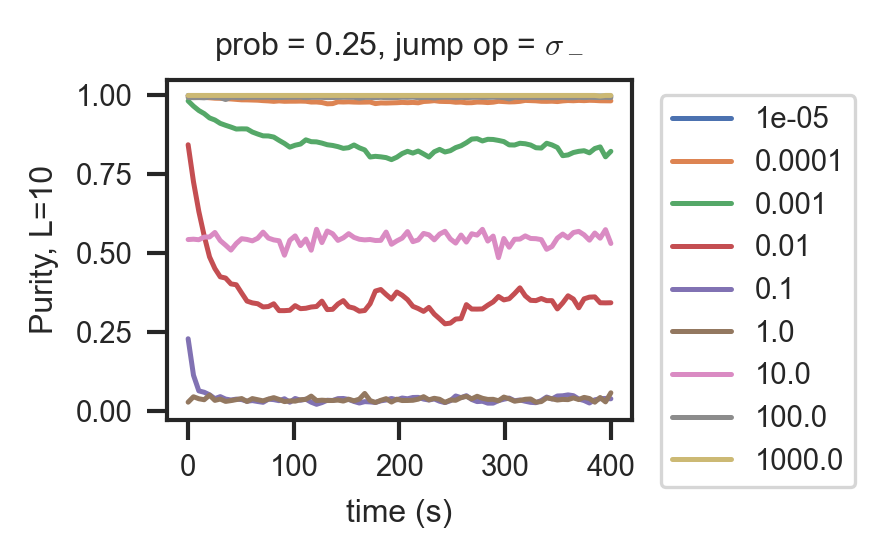

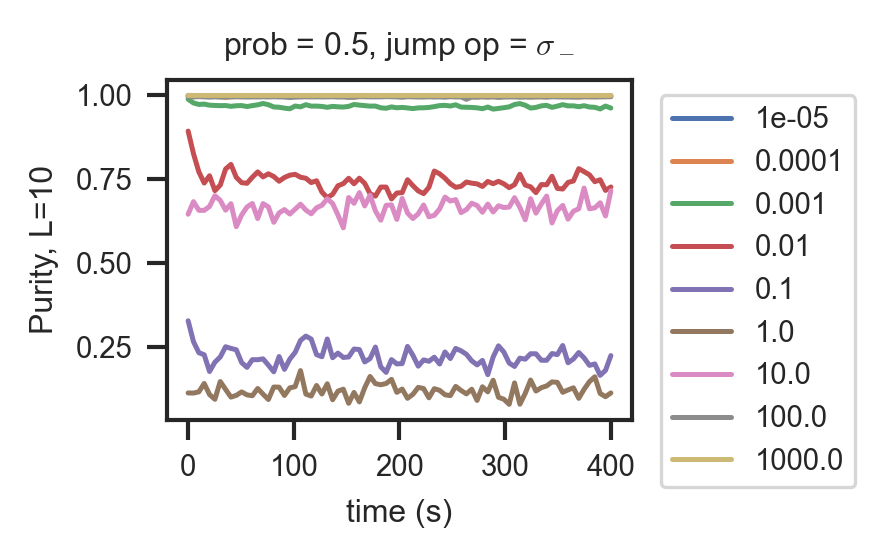

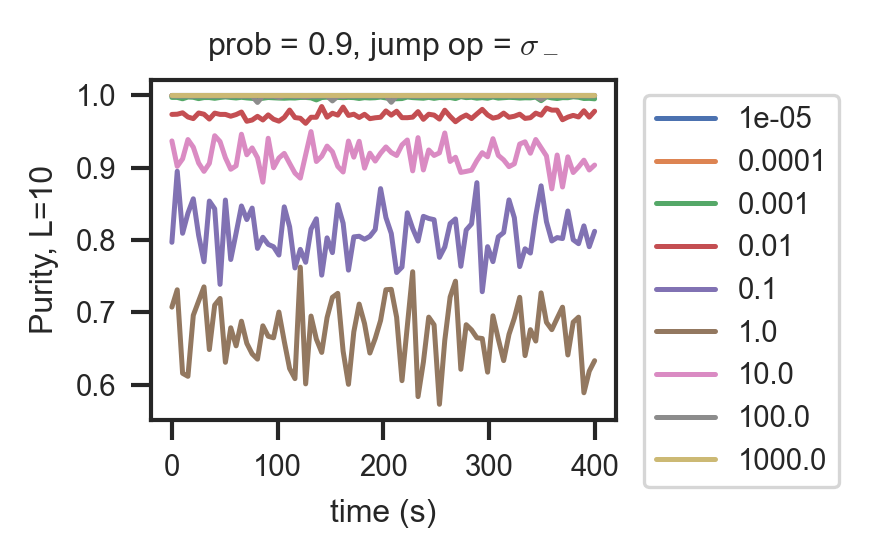

In [77]:
#rateList = np.sort(np.array(rateList))

t_total = 400
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt))

plt.figure()
for rates in rateList:
    plt.plot(duration, avgedP_dynamics_1[rates][0.25],'-')

plt.xlabel('time (s)') 
plt.ylabel('Purity, L=10')
plt.title(r'prob = 0.25, jump op = $\sigma_-$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )

plt.figure()
for rates in rateList:
    plt.plot(duration, avgedP_dynamics_1[rates][0.5],'-')

plt.xlabel('time (s)') 
plt.ylabel('Purity, L=10')
plt.title(r'prob = 0.5, jump op = $\sigma_-$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )



plt.figure()
for rates in rateList:
    plt.plot(duration, avgedP_dynamics_1[rates][0.9],'-')

plt.xlabel('time (s)') 
plt.ylabel('Purity, L=10')
plt.title(r'prob = 0.9, jump op = $\sigma_-$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )



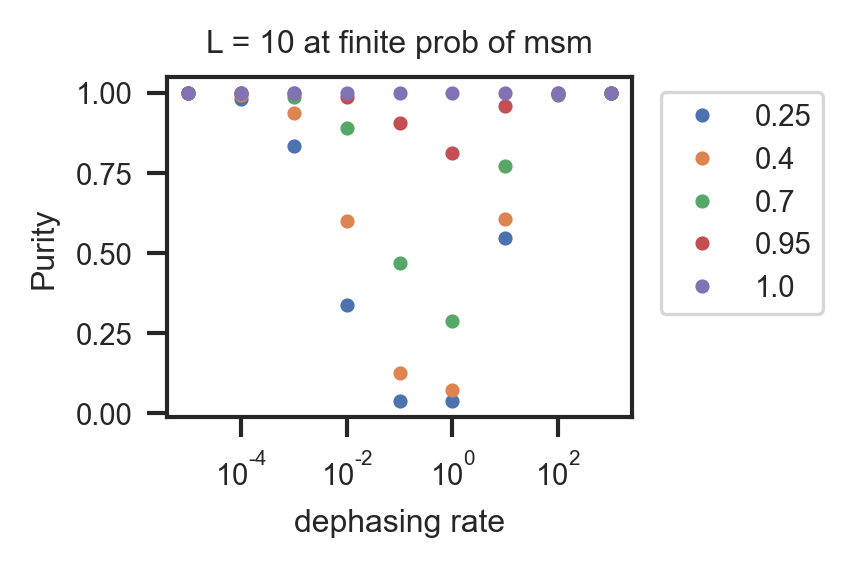

In [86]:
# Extract S(L/2) as a function of the dephasing rate at finite probability of msm
rateList = rateList1 + rateList2 + rateList3

rateList = np.logspace(-5,3,9)

probTempList = [0.25, 0.4, 0.7, 0.95, 1.0] #np.linspace(0.1, 1, 4)


plt.figure()
for prob in probTempList:
    PinRate = np.zeros(len(rateList))
    for (r,rate) in enumerate(rateList):
        #print(rate,prob)
        #print(avgedP_dynamics_1[rate][prob])
        steps = len(avgedP_dynamics_1[rate][prob])
        PinRate[r] = np.average(avgedP_dynamics_1[rate][prob][steps//2:])
        
    #print(PinRate)

    plt.semilogx(np.array(rateList).astype(float), PinRate,'.')
    plt.xlabel('dephasing rate')
    plt.ylabel('Purity')
plt.title('L = 10 at finite prob of msm')
plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
print()
